In [ ]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print(path)
print(os.listdir(path))

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
/kaggle/input/telco-customer-churn
['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [ ]:
csv_file = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")

df = pd.read_csv(csv_file)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


DATA EXPLORATION

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
df["TotalCharges"].head(10)

,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65
5,820.5
6,1949.4
7,301.9
8,3046.05
9,3487.95


In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [ ]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [ ]:
df = df.dropna(subset=["TotalCharges"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

Create Useful Columns

In [ ]:
df["CustomerStatus"] = df["Churn"].map({
    "Yes": "Churned",
    "No": "Retained"
})

In [ ]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0,12,24,48,72],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-72 Months"
    ]
)

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7032 non-null   object  
 1   gender            7032 non-null   object  
 2   SeniorCitizen     7032 non-null   int64   
 3   Partner           7032 non-null   object  
 4   Dependents        7032 non-null   object  
 5   tenure            7032 non-null   int64   
 6   PhoneService      7032 non-null   object  
 7   MultipleLines     7032 non-null   object  
 8   InternetService   7032 non-null   object  
 9   OnlineSecurity    7032 non-null   object  
 10  OnlineBackup      7032 non-null   object  
 11  DeviceProtection  7032 non-null   object  
 12  TechSupport       7032 non-null   object  
 13  StreamingTV       7032 non-null   object  
 14  StreamingMovies   7032 non-null   object  
 15  Contract          7032 non-null   object  
 16  PaperlessBilling  7032 non-nu

Calculate KPIs

In [ ]:
# Total Customers
total_customers = len(df)

# Churned Customers
churned_customers = len(df[df["Churn"] == "Yes"])

# Retained Customers
retained_customers = len(df[df["Churn"] == "No"])

# Churn Rate
churn_rate = (churned_customers / total_customers) * 100

# Retention Rate
retention_rate = (retained_customers / total_customers) * 100

# Average Tenure
average_tenure = df["tenure"].mean()

print(f"Total Customers: {total_customers}")
print(f"Churned Customers: {churned_customers}")
print(f"Retained Customers: {retained_customers}")
print(f"Churn Rate: {churn_rate:.2f}%")
print(f"Retention Rate: {retention_rate:.2f}%")
print(f"Average Customer Tenure: {average_tenure:.2f} months")

Total Customers: 7032
Churned Customers: 1869
Retained Customers: 5163
Churn Rate: 26.58%
Retention Rate: 73.42%
Average Customer Tenure: 32.42 months


In [ ]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "Churned Customers",
        "Retained Customers",
        "Churn Rate",
        "Retention Rate",
        "Average Tenure (Months)"
    ],
    "Value": [
        total_customers,
        churned_customers,
        retained_customers,
        f"{churn_rate:.2f}%",
        f"{retention_rate:.2f}%",
        round(average_tenure, 2)
    ]
})

kpi_summary

,KPI,Value
0,Total Customers,7032
1,Churned Customers,1869
2,Retained Customers,5163
3,Churn Rate,26.58%
4,Retention Rate,73.42%
5,Average Tenure (Months),32.42


Churn by Contract Type

In [ ]:
contract_churn = (
    df.groupby(["Contract", "Churn"])
      .size()
      .unstack()
      .fillna(0)
)

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


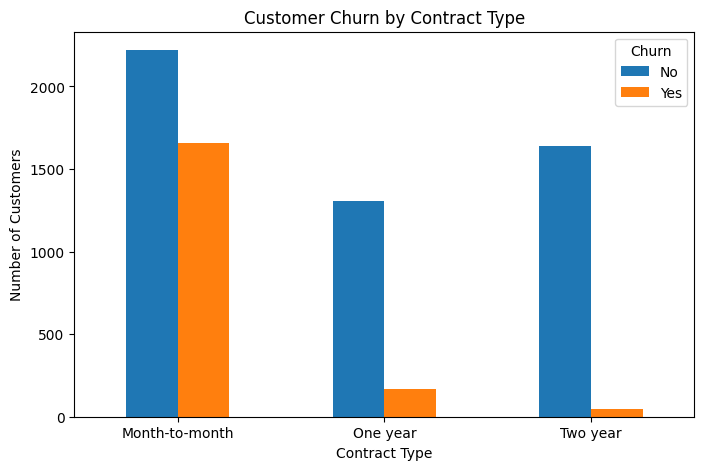

In [ ]:
import matplotlib.pyplot as plt

contract_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

Churn by Tenure

<Figure size 800x500 with 0 Axes>

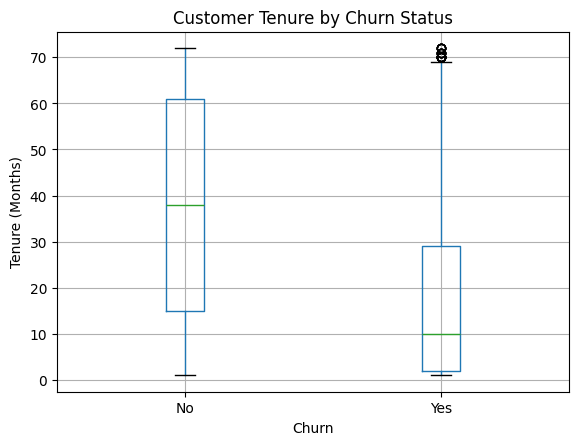

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df.boxplot(column="tenure", by="Churn")

plt.title("Customer Tenure by Churn Status")
plt.suptitle("")   # Removes automatic title
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

Internet Service vs Churn

In [ ]:
internet_churn = (
    df.groupby(["InternetService", "Churn"])
      .size()
      .unstack()
      .fillna(0)
)

internet_churn

Churn,No,Yes
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


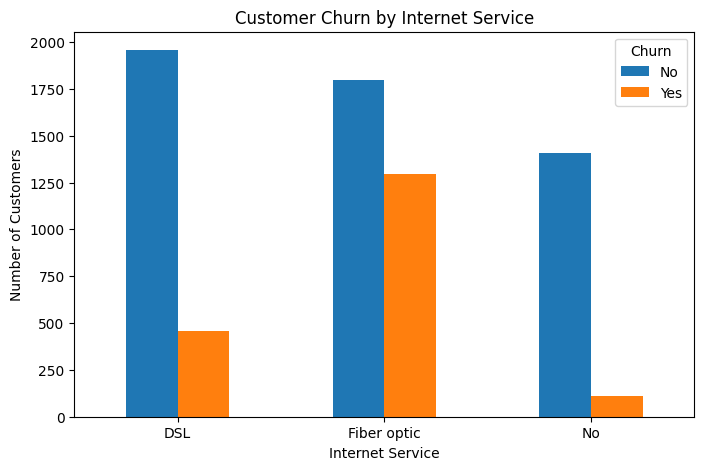

In [ ]:
internet_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

Payment Method vs Churn

In [ ]:
payment_churn = (
    df.groupby(["PaymentMethod", "Churn"])
      .size()
      .unstack()
      .fillna(0)
)

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


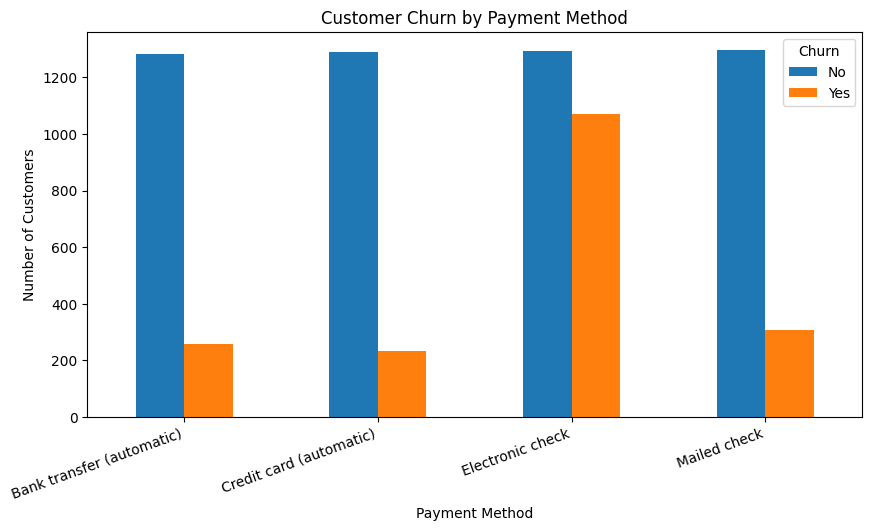

In [ ]:
import matplotlib.pyplot as plt

payment_churn.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20, ha="right")

plt.show()

Monthly Charges vs Churn

<Figure size 800x500 with 0 Axes>

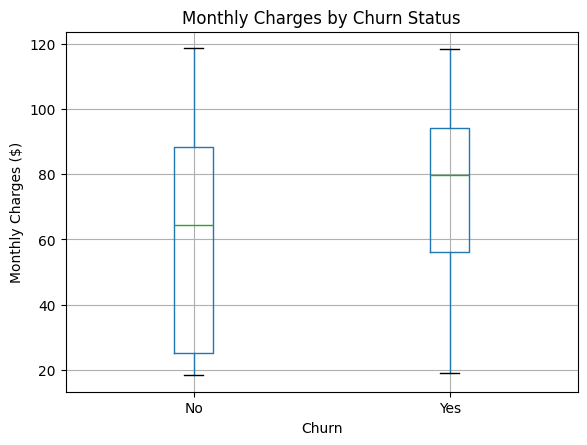

In [ ]:
plt.figure(figsize=(8,5))

df.boxplot(column="MonthlyCharges", by="Churn")

plt.title("Monthly Charges by Churn Status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges ($)")

plt.show()

Churn by Senior Citizen

In [ ]:
senior_churn = (
    df.groupby(["SeniorCitizen", "Churn"])
      .size()
      .unstack()
      .fillna(0)
)

senior_churn

Churn,No,Yes
SeniorCitizen,,
0,4497,1393
1,666,476


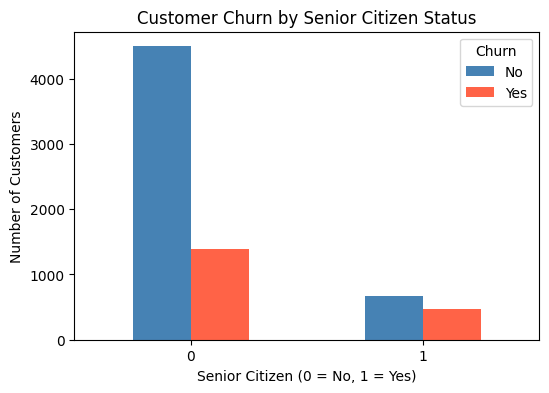

In [ ]:
import matplotlib.pyplot as plt

senior_churn.plot(
    kind="bar",
    figsize=(6,4),
    color=["steelblue", "tomato"]
)

plt.title("Customer Churn by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

In [ ]:
df.to_csv("telco_customer_churn_cleaned.csv", index=False)

In [ ]:
from google.colab import files

files.download("telco_customer_churn_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>